##  🎬 Recommendation Systems Workshop
### MovieLens Dataset, AIC 4/17/26

**Goal:** Build and compare recommendation approaches using the MovieLens dataset and the `recommenders` library.

**Outline:**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Approach 1: Content-Based Filtering
4. Approach 2: Collaborative Filtering (Memory-Based)
5. Approach 3: Collaborative Filtering (Model-Based — SVD/ALS)
6. Evaluation & Comparison
7. Discussion: Cold Start, Bias, and Beyond

**Note**: Cells marked with a ✏️ are for you to experiment with!

---

## 0. Install Dependencies

> ⚠️ Be sure to run `uv sync` to install all necessary dependencies. The `recommenders` library from Microsoft wraps many recsys algorithms cleanly.



## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# recommenders utilities
from recommenders.datasets import movielens
from recommenders.datasets.python_splitters import python_random_split
from recommenders.evaluation.python_evaluation import (
    rmse, mae, precision_at_k, recall_at_k, ndcg_at_k
)

# Surprise for collaborative filtering
from surprise import SVD, KNNBasic, Dataset, Reader
from surprise.model_selection import cross_validate

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# -------------------------------------------------------
# Load MovieLens 100K dataset via the recommenders library
# Size options: '100k', '1m', '10m', '20m'
# 100k is great for live demos — fast and manageable
# -------------------------------------------------------

MOVIELENS_DATA_SIZE = '100k'
# Column names for the dataset
COL_USER = "userID"
COL_ITEM = "itemID"
COL_RATING = "rating"
COL_TIMESTAMP = "timestamp"

df = movielens.load_pandas_df(
    size=MOVIELENS_DATA_SIZE,
    header=[COL_USER, COL_ITEM, COL_RATING, COL_TIMESTAMP],
    local_cache_path='./movielens_data'

)

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (100000, 4)


,userID,itemID,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596
5,298,474,4.0,884182806
6,115,265,2.0,881171488
7,253,465,5.0,891628467
8,305,451,3.0,886324817
9,6,86,3.0,883603013


In [6]:
# Also load movie metadata (titles, genres)
movies_df = movielens.load_item_df(
    size=MOVIELENS_DATA_SIZE,
    movie_col='itemID',
    title_col='title',
    genres_col='genres',
    local_cache_path='./movielens_meta'
)

movies_df.head()

,itemID,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,GoldenEye (1995),Action|Adventure|Thriller
2,3,Four Rooms (1995),Thriller
3,4,Get Shorty (1995),Action|Comedy|Drama
4,5,Copycat (1995),Crime|Drama|Thriller


## 2. Exploratory Data Analysis (EDA)

> 💡 Before building any model, it is crucial to understand your data. This is true in all ML, and especially in recommendation systems where data is very sparse.

In [7]:
# Basic statistics
n_users = df['userID'].nunique()
n_items = df['itemID'].nunique()
n_ratings = len(df)
sparsity = 1 - (n_ratings / (n_users * n_items))

print(f"👤 Users:    {n_users}")
print(f"🎬 Movies:   {n_items}")
print(f"⭐ Ratings:  {n_ratings}")
print(f"🕳️  Sparsity: {sparsity:.2%}")
print()
print("➡️  This means we only observe", f"{1-sparsity:.2%}", "of all possible user-item pairs.")
print("    The recommendation problem is fundamentally about filling in the blanks!")

👤 Users:    943
🎬 Movies:   1682
⭐ Ratings:  100000
🕳️  Sparsity: 93.70%

➡️  This means we only observe 6.30% of all possible user-item pairs.
    The recommendation problem is fundamentally about filling in the blanks!


> We will now visualize how the given ratings are distributed and look at rating frequency per user and per movie

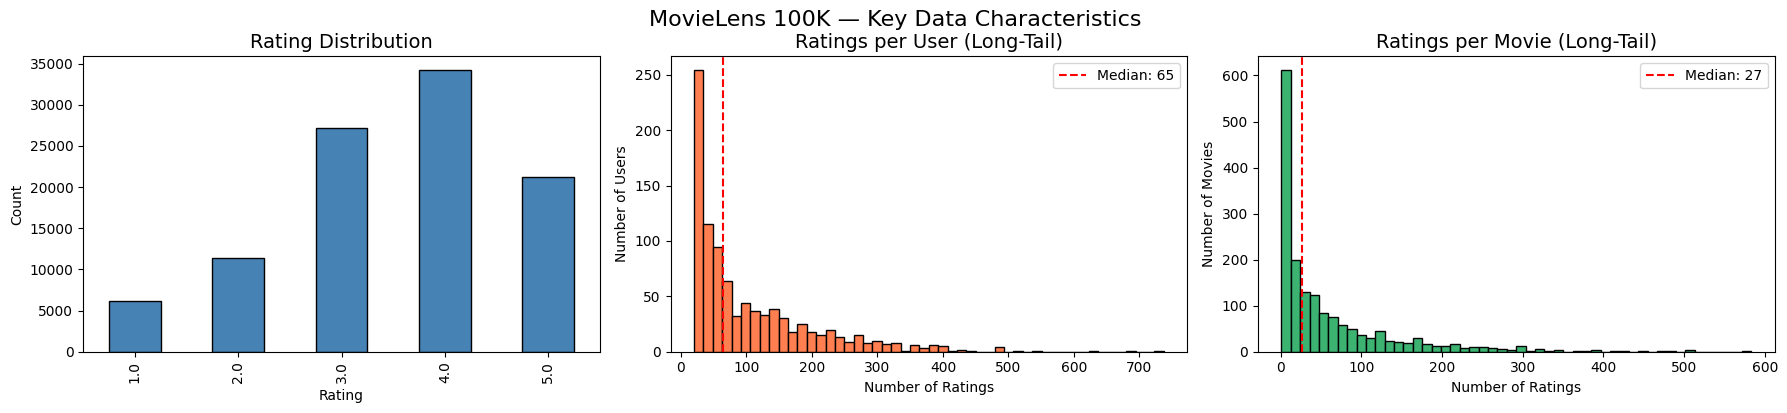


💡 Notice the long tail — most users rate few movies, most movies get few ratings.
   This is the reality that makes recommendation hard (and interesting)!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Rating distribution
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user (long-tail)
ratings_per_user = df.groupby('userID')['rating'].count()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Ratings per User (Long-Tail)', fontsize=14)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(ratings_per_user.median(), color='red', linestyle='--', label=f'Median: {ratings_per_user.median():.0f}')
axes[1].legend()

# Ratings per movie (long-tail)
ratings_per_movie = df.groupby('itemID')['rating'].count()
axes[2].hist(ratings_per_movie, bins=50, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Ratings per Movie (Long-Tail)', fontsize=14)
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Number of Movies')
axes[2].axvline(ratings_per_movie.median(), color='red', linestyle='--', label=f'Median: {ratings_per_movie.median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.suptitle('MovieLens 100K — Key Data Characteristics', fontsize=16, y=1.02)
plt.show()

print("\n💡 Notice the long tail — most users rate few movies, most movies get few ratings.")
print("   This is the reality that makes recommendation hard (and interesting)!")

In [11]:
# Most-rated movies
top_movies = (
    df.groupby('itemID')['rating']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'num_ratings', 'mean': 'avg_rating'})
    .merge(movies_df[['itemID', 'title']], left_index=True, right_on='itemID')
    .sort_values('num_ratings', ascending=False)
    .head(10)
)

print("🏆 Top 10 Most-Rated Movies:")
top_movies

🏆 Top 10 Most-Rated Movies:


,num_ratings,avg_rating,itemID,title
49,583,4.358491,50,Star Wars (1977)
257,509,3.803536,258,Contact (1997)
99,508,4.155512,100,Fargo (1996)
180,507,4.007890,181,Return of the Jedi (1983)
293,485,3.156701,294,Liar Liar (1997)
285,481,3.656965,286,"English Patient, The (1996)"
287,478,3.441423,288,Scream (1996)
0,452,3.878319,1,Toy Story (1995)
299,431,3.631090,300,Air Force One (1997)
120,429,3.438228,121,Independence Day (ID4) (1996)


## 3. Approach 1: Content-Based Filtering

> **Core Idea:** Recommend movies that are *similar to movies a user already liked*, based on item features (genres here).
>
> **ML Connection:** This is essentially a feature similarity problem — we build item profiles based on genre and compute cosine similarity.
>
> **Limitation:** Only recommends within a user's existing taste bubble and considers each to be independent.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build a genre-based item profile using TF-IDF
# Genres in MovieLens look like: "Action|Adventure|Comedy"
# We treat each genre string as a small "document"
# You are welcome to also try out another embedding algorithm

movies_clean = movies_df.dropna(subset=['genres']).copy()
movies_clean['genres_clean'] = movies_clean['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_clean['genres_clean'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary (genres): {list(tfidf.vocabulary_.keys())}")

TF-IDF matrix shape: (1682, 21)
Vocabulary (genres): ['animation', 'children', 'comedy', 'action', 'adventure', 'thriller', 'drama', 'crime', 'sci', 'fi', 'war', 'romance', 'horror', 'musical', 'documentary', 'western', 'fantasy', 'film', 'noir', 'mystery', 'unknown']


In [16]:
# each movie's "profile" is encoded as a sparse TF-IDF vector of size 21 (vocabulary)
print(tfidf_matrix[0].toarray())

[[0.         0.         0.74066017 0.57387209 0.34941857 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]]


In [18]:
# Compute pairwise cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Cosine Sim Matrix Shape: {cosine_sim.shape}")

# Build a lookup: title -> index
movies_clean = movies_clean.reset_index(drop=True)
title_to_idx = pd.Series(movies_clean.index, index=movies_clean['title'])

title_to_idx.head()

Cosine Sim Matrix Shape: (1682, 1682)


title
Toy Story (1995)     0
GoldenEye (1995)     1
Four Rooms (1995)    2
Get Shorty (1995)    3
Copycat (1995)       4
dtype: int64

In [23]:
# defining function for content-based filitering
def get_content_based_recs(title, n=10):
    """Return top-N movies most similar to 'title' by genre."""
    if title not in title_to_idx:
        print(f"Movie '{title}' not found. Try a different title.")
        return
    
    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) # sort descending
    sim_scores = [pair for pair in sim_scores if pair[0] != idx][:n]  # exclude self before taking top-n
    
    # get indices and scores of top-10 most similar movies
    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 3) for i in sim_scores]
    
    result = movies_clean.iloc[movie_indices][['title', 'genres']].copy()
    result['similarity_score'] = scores
    return result

# 🎬 Try it! Change this to any movie title in the dataset
TARGET_MOVIE = "Batman Forever (1995)"

recs = get_content_based_recs(TARGET_MOVIE, n=10)
print(f"\n🎯 Content-Based Recommendations for '{TARGET_MOVIE}':\n")
print(recs.to_string(index=False))


🎯 Content-Based Recommendations for 'Batman Forever (1995)':

                       title                          genres  similarity_score
       Batman Returns (1992)   Action|Adventure|Comedy|Crime             1.000
  Rumble in the Bronx (1995)          Action|Adventure|Crime             0.937
       Batman & Robin (1997)          Action|Adventure|Crime             0.937
          Cliffhanger (1993)          Action|Adventure|Crime             0.937
               Batman (1989)    Action|Adventure|Crime|Drama             0.894
          Hard Target (1993) Action|Adventure|Crime|Thriller             0.840
Three Musketeers, The (1993)         Action|Adventure|Comedy             0.805
             Best Men (1997)       Action|Comedy|Crime|Drama             0.782
           Set It Off (1996)                    Action|Crime             0.751
         New York Cop (1996)                    Action|Crime             0.751


In [24]:
# ✏️ EXERCISE: Try a few different movies and notice patterns
# What happens with an action movie vs. a drama vs. a comedy?

for movie in ["Star Wars (1977)", "Fargo (1996)", "GoodFellas (1990)"]:
    recs = get_content_based_recs(movie, n=3)
    print(f"\n'{movie}' → Top 3:")
    if recs is not None:
        print(recs[['title', 'genres', 'similarity_score']].to_string(index=False))


'Star Wars (1977)' → Top 3:
                          title                                    genres  similarity_score
      Return of the Jedi (1983)       Action|Adventure|Romance|Sci-Fi|War             1.000
Empire Strikes Back, The (1980) Action|Adventure|Drama|Romance|Sci-Fi|War             0.978
       Starship Troopers (1997)               Action|Adventure|Sci-Fi|War             0.942

'Fargo (1996)' → Top 3:
                    title               genres  similarity_score
           Copycat (1995) Crime|Drama|Thriller               1.0
Desperate Measures (1998) Crime|Drama|Thriller               1.0
    Kiss the Girls (1997) Crime|Drama|Thriller               1.0

'GoodFellas (1990)' → Top 3:
               title      genres  similarity_score
 Pulp Fiction (1994) Crime|Drama               1.0
Carlito's Way (1993) Crime|Drama               1.0
Donnie Brasco (1997) Crime|Drama               1.0


## 4. Approach 2: Collaborative Filtering (Memory-Based / KNN)

> **Core Idea:** Find users who behaved *similarly* to you and recommend what they liked.
> No item features needed as recommendations emerge entirely from interaction patterns.
>
> **ML Connection:** Nearest-neighbor search in user-behavior space. Think KNN, but on ratings vectors.
>
> **Two flavors:**
> - **User-User CF:** Find similar users → borrow their ratings
> - **Item-Item CF:** Find similar items → recommend items similar to what you rated highly

In [25]:
# Train/test split (80/20)
train_df, test_df = python_random_split(df, ratio=0.80, seed=42)

print(f"Train size: {len(train_df):,}")
print(f"Test size:  {len(test_df):,}")

Train size: 80,000
Test size:  20,000


In [26]:
# Prepare data for Surprise library
reader = Reader(rating_scale=(1, 5))

train_surprise = Dataset.load_from_df(train_df[['userID', 'itemID', 'rating']], reader)
trainset = train_surprise.build_full_trainset()

# --- User-User KNN ---
# sim_options: pearson correlation, user-based (vs. item-based)
# we use pearson correlation vs. cos_sim to account for user rating bias
user_knn = KNNBasic(
    k=40,              # number of neighbors
    sim_options={'name': 'pearson', 'user_based': True},
    verbose=False
)
user_knn.fit(trainset)

# --- Item-Item KNN ---
# same calculations as above but the transpose
item_knn = KNNBasic(
    k=40,
    sim_options={'name': 'pearson', 'user_based': False},
    verbose=False
)
item_knn.fit(trainset)

print("✅ KNN models trained!")

✅ KNN models trained!


In [33]:
def predict_ratings(model, test_df):
    """Generate predictions for all user-item pairs in test set."""
    preds = []
    for _, row in test_df.iterrows():
        pred = model.predict(row['userID'], row['itemID'])
        preds.append({
            'userID': row['userID'],
            'itemID': row['itemID'],
            'rating': row['rating'],
            'prediction': pred.est
        })
    return pd.DataFrame(preds)

print("Generating predictions...")
user_knn_preds = predict_ratings(user_knn, test_df)
item_knn_preds = predict_ratings(item_knn, test_df)
print("✅ Done!")

Generating predictions...
✅ Done!


In [34]:
user_knn_preds.head()

,userID,itemID,rating,prediction
0,877.0,381.0,4.0,3.883444
1,815.0,602.0,3.0,3.566163
2,94.0,431.0,4.0,3.409217
3,416.0,875.0,2.0,2.803376
4,500.0,182.0,2.0,4.279024


In [35]:
item_knn_preds.head()

,userID,itemID,rating,prediction
0,877.0,381.0,4.0,4.084007
1,815.0,602.0,3.0,3.949046
2,94.0,431.0,4.0,3.439349
3,416.0,875.0,2.0,3.649079
4,500.0,182.0,2.0,2.962229


## 5. Approach 3: Model-Based Collaborative Filtering (SVD)

> **Core Idea:** Decompose the user-item rating matrix into latent factors using Singular Value Decomposition (SVD).
> Instead of storing every rating, we learn compact *user embeddings* and *item embeddings*.
>
> **ML Connection:** Matrix factorization — the backbone of the Netflix Prize-winning approach.
> Think of it as dimensionality reduction (like PCA) applied to the ratings matrix.
>
> **Why it wins:** Generalizes better, handles sparsity more gracefully, scales to millions of users.

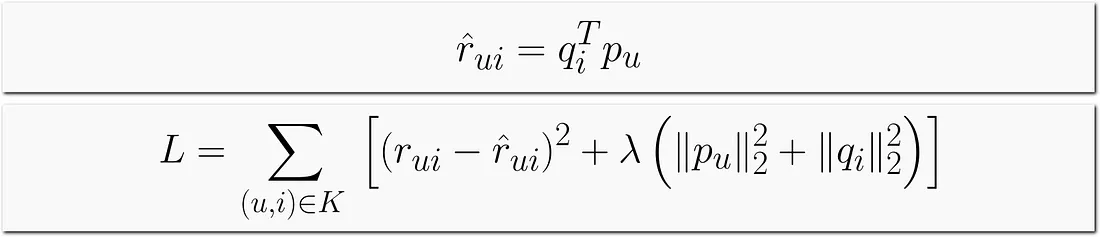

In [36]:
# SVD via Surprise (Funk SVD / Matrix Factorization)
# ✏️ Try tweaking: n_factors (embedding size), n_epochs, lr_all, reg_all

svd_model = SVD(
    n_factors=50,     # size of latent space (user/item embedding dim)
    n_epochs=20,      # training epochs
    lr_all=0.005,     # learning rate
    reg_all=0.02,     # regularization (prevents overfitting)
    random_state=42,
    verbose=False
)

svd_model.fit(trainset)
print("✅ SVD model trained!")
print(f"\nLearned {svd_model.n_factors} latent factors for:")
print(f"  - {trainset.n_users} users")
print(f"  - {trainset.n_items} items")

✅ SVD model trained!

Learned 50 latent factors for:
  - 943 users
  - 1653 items


In [37]:
svd_preds = predict_ratings(svd_model, test_df)

# Quick peek at predictions vs. actual
sample = svd_preds.sample(5, random_state=1)
sample['error'] = abs(sample['prediction'] - sample['rating'])
print("Sample predictions:")
print(sample.to_string(index=False))

Sample predictions:
 userID  itemID  rating  prediction    error
  199.0   242.0     5.0    3.643228 1.356772
    7.0   657.0     4.0    4.855611 0.855611
  373.0   480.0     3.0    4.519086 1.519086
   56.0   219.0     5.0    3.962966 1.037034
  623.0   210.0     5.0    4.012506 0.987494


In [40]:
# Personalized recommendation for a specific user
def get_top_n_svd(user_id, model, movies_df, all_ratings_df, n=10):
    """Get top-N unseen movie recommendations for a user using SVD."""
    # Movies already rated by this user
    rated_items = all_ratings_df[all_ratings_df['userID'] == user_id]['itemID'].tolist()
    
    # All movies the user hasn't seen
    all_items = movies_df['itemID'].tolist()
    unseen_items = [i for i in all_items if i not in rated_items]
    
    # Predict ratings for unseen movies
    predictions = [(item, model.predict(user_id, item).est) for item in unseen_items]
    predictions.sort(key=lambda x: x[1], reverse=True) # sort by rating prediction
    
    top_items = [p[0] for p in predictions[:n]]
    top_scores = [round(p[1], 2) for p in predictions[:n]]
    
    result = movies_df[movies_df['itemID'].isin(top_items)].copy() # get movie metadata
    score_map = dict(zip(top_items, top_scores))
    result['predicted_rating'] = result['itemID'].map(score_map) # map score to movie id
    return result.sort_values('predicted_rating', ascending=False)[['title', 'genres', 'predicted_rating']]

In [41]:
# ✏️ Change USER_ID to explore different users!
USER_ID = 42
print(f"\n🎬 Top 10 SVD Recommendations for User {USER_ID}:\n")
print(get_top_n_svd(USER_ID, svd_model, movies_df, df, n=10).to_string(index=False))


🎬 Top 10 SVD Recommendations for User 42:

                                                      title            genres  predicted_rating
                                        Citizen Kane (1941)             Drama              4.68
                                    Jean de Florette (1986)             Drama              4.64
                                          Braveheart (1995)  Action|Drama|War              4.58
                                   Good Will Hunting (1997)             Drama              4.58
                      Day the Earth Stood Still, The (1951)      Drama|Sci-Fi              4.49
Paradise Lost: The Child Murders at Robin Hood Hills (1996)       Documentary              4.48
                                          Casablanca (1942) Drama|Romance|War              4.47
                                        Blade Runner (1982)  Film-Noir|Sci-Fi              4.44
                                 Maltese Falcon, The (1941) Film-Noir|Mystery              4

## 6. Evaluation & Comparison

> **Key metrics in recsys:**
> - **RMSE / MAE** — Rating prediction accuracy (lower = better)
> - **Precision@K** — Of the top-K recommended items, how many did the user actually like?
> - **Recall@K** — Of all items the user liked, how many did we surface in top-K?
> - **NDCG@K** — Normalized Discounted Cumulative Gain: rewards putting the *best* items at the *top*

In [45]:
user_knn_preds

,userID,itemID,rating,prediction
0,877.0,381.0,4.0,3.883444
1,815.0,602.0,3.0,3.566163
2,94.0,431.0,4.0,3.409217
3,416.0,875.0,2.0,2.803376
4,500.0,182.0,2.0,4.279024
...,...,...,...,...
19995,72.0,591.0,5.0,3.620199
19996,523.0,393.0,5.0,3.708433
19997,606.0,287.0,4.0,3.626846
19998,650.0,612.0,4.0,3.940277


In [48]:
# Rating prediction metrics for each of three approaches
results = {}

for name, preds in [("User-KNN", user_knn_preds), ("Item-KNN", item_knn_preds), ("SVD", svd_preds)]:
    rating_true = preds[["userID", "itemID", "rating"]]
    rating_pred = preds[["userID", "itemID", "prediction"]]
    results[name] = {
        'RMSE': round(rmse(rating_true, rating_pred, col_user='userID', col_item='itemID',
                           col_rating='rating', col_prediction='prediction'), 4),
        'MAE':  round(mae(rating_true, rating_pred,  col_user='userID', col_item='itemID',
                          col_rating='rating', col_prediction='prediction'), 4),
    }

results_df = pd.DataFrame(results).T
print("📊 Rating Prediction Accuracy:")
print(results_df.to_string())
print("\n(Lower is better for RMSE and MAE)")

📊 Rating Prediction Accuracy:
            RMSE     MAE
User-KNN  1.0075  0.7977
Item-KNN  1.0406  0.8338
SVD       0.9313  0.7337

(Lower is better for RMSE and MAE)


In [55]:
# Ranking metrics: Precision@K, Recall@K, NDCG@K
K = 10
RATING_THRESHOLD = 3.5  # treat >=3.5 as "liked"

ranking_results = {}

for name, preds in [("User-KNN", user_knn_preds), ("Item-KNN", item_knn_preds), ("SVD", svd_preds)]:
    rating_true = preds[["userID", "itemID", "rating"]]
    rating_pred = preds[["userID", "itemID", "prediction"]]
    
    ranking_results[name] = {
        f"Precision@{K}": round(precision_at_k(
            rating_true, rating_pred, col_user="userID", col_item="itemID",
            col_rating="rating", col_prediction="prediction",
            k=K, threshold=RATING_THRESHOLD), 4),
        f"Recall@{K}": round(recall_at_k(
            rating_true, rating_pred, col_user="userID", col_item="itemID",
            col_rating="rating", col_prediction="prediction",
            k=K, threshold=RATING_THRESHOLD), 4),
        f"NDCG@{K}": round(ndcg_at_k(
            rating_true, rating_pred, col_user="userID", col_item="itemID",
            col_rating="rating", col_prediction="prediction",
            k=K), 4),
    }

ranking_df = pd.DataFrame(ranking_results).T
print(f"📊 Ranking Quality (K={K}, threshold={RATING_THRESHOLD}):")
print(ranking_df.to_string())
print("\n(Higher is better for Precision, Recall, and NDCG)")

📊 Ranking Quality (K=10, threshold=3.5):
          Precision@10  Recall@10  NDCG@10
User-KNN        0.8315     0.6716      1.0
Item-KNN        0.8315     0.6716      1.0
SVD             0.8315     0.6716      1.0

(Higher is better for Precision, Recall, and NDCG)


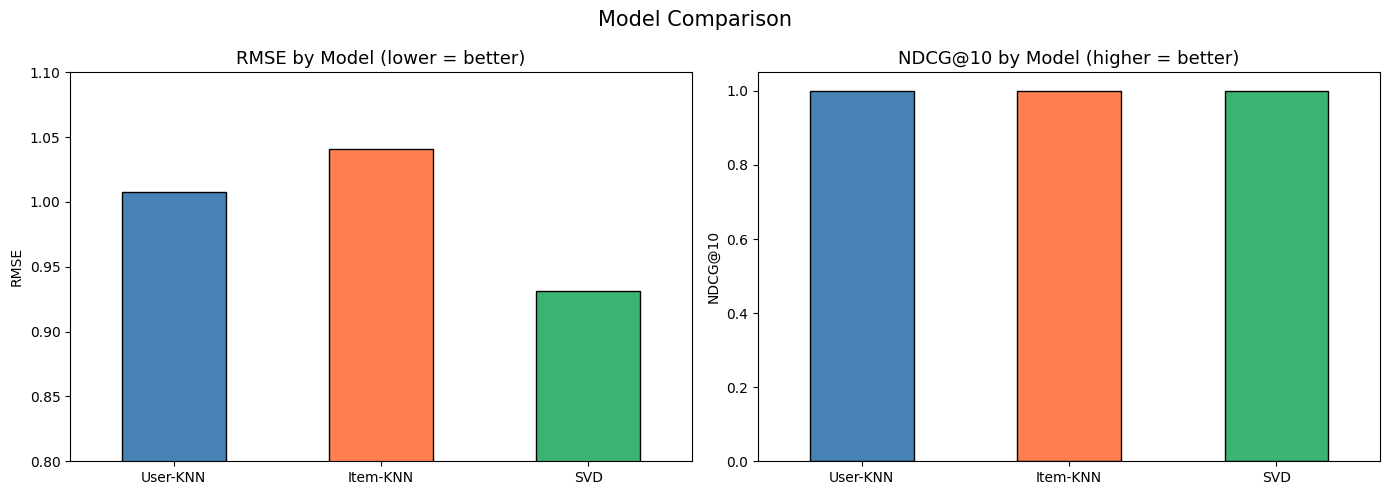

In [53]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE bar chart
results_df['RMSE'].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
axes[0].set_title('RMSE by Model (lower = better)', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(results_df.index, rotation=0)
axes[0].set_ylim(0.8, 1.1)

# NDCG@K bar chart
ranking_df[f'NDCG@{K}'].plot(kind='bar', ax=axes[1], color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
axes[1].set_title(f'NDCG@{K} by Model (higher = better)', fontsize=13)
axes[1].set_ylabel(f'NDCG@{K}')
axes[1].set_xticklabels(ranking_df.index, rotation=0)

plt.suptitle('Model Comparison', fontsize=15)
plt.tight_layout()
plt.show()

## 7. ✏️ Hyperparameter Exploration

> **WORKSHOP ACTIVITY:** Tweak these parameters and re-run to see how metrics change.
> This builds intuition for the bias-variance tradeoff in collaborative filtering.

In [ ]:
# ✏️ Experiment: How does the number of latent factors affect SVD quality?

# feel free to also use GridSearchCV for hyperparameter tuning

factor_results = []

for n_factors in [5, 10, 25, 50, 100, 200]:
    model = SVD(n_factors=n_factors, n_epochs=20, random_state=42, verbose=False)
    model.fit(trainset)
    preds = predict_ratings(model, test_df)
    factor_results.append({
        'n_factors': n_factors,
        'RMSE': round(rmse(preds, col_user='userID', col_item='itemID',
                           col_rating='rating', col_prediction='prediction'), 4)
    })
    print(f"  n_factors={n_factors:3d}  →  RMSE={factor_results[-1]['RMSE']}")

factor_df = pd.DataFrame(factor_results)

plt.figure(figsize=(8, 4))
plt.plot(factor_df['n_factors'], factor_df['RMSE'], marker='o', color='steelblue')
plt.xlabel('Number of Latent Factors')
plt.ylabel('RMSE (Test)')
plt.title('SVD: Latent Factors vs. RMSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Notice: too few factors = underfitting, too many = overfitting")

In [59]:
# ✏️ BONUS EXERCISE: Build a simple popularity-based baseline
# The simplest possible recommender — recommend the most popular movies to everyone.
# How does it compare to our fancy models on RMSE? (You might be surprised!)

global_mean = train_df['rating'].mean()
item_means = train_df.groupby('itemID')['rating'].mean()

baseline_preds = test_df.copy()
# fill with item based means
baseline_preds['prediction'] = baseline_preds['itemID'].map(item_means).fillna(global_mean)

baseline_rmse = rmse(
    rating_true=baseline_preds[["userID", "itemID", "rating"]],
    rating_pred=baseline_preds[["userID", "itemID", "prediction"]],
    col_user='userID', col_item='itemID',
    col_rating='rating', col_prediction='prediction'
)

print(f"📊 Popularity Baseline RMSE: {baseline_rmse:.4f}")
print(f"📊 SVD RMSE:                 {results['SVD']['RMSE']}")
print()
print("💡 Baselines matter! Always compare against simple heuristics.")
print("   In production, a simple popularity recommender often outperforms complex models")
print("   in A/B tests — because popularity = social proof.")

📊 Popularity Baseline RMSE: 1.0210
📊 SVD RMSE:                 0.9313

💡 Baselines matter! Always compare against simple heuristics.
   In production, a simple popularity recommender often outperforms complex models
   in A/B tests — because popularity = social proof.


## 8. Discussion: Open Problems

---

### 🧊 The Cold-Start Problem
- **New user cold start:** A brand new user has zero ratings. How do you recommend anything?
  - *Ideas:* Ask onboarding questions, use demographic features, default to popular items
- **New item cold start:** A new movie has zero ratings. How does it ever get recommended?
  - *Ideas:* Content-based fallback, explore-exploit strategies

---

### 🎰 Exploration vs. Exploitation
- If you only recommend what you know a user likes, they never discover anything new.
- This is a **multi-armed bandit** problem! (RL connection)
- Strategies: ε-greedy, UCB, Thompson Sampling applied to recommendations

---

### ⚖️ Fairness & Filter Bubbles
- Recommenders can amplify popularity bias (popular items get more exposure → more ratings → ranked higher)
- Filter bubbles: users only see content matching their existing views
- How do we measure and mitigate this?

---

### 🚀 What's Next? (Modern Approaches)
- **Hybrid Approaches**: Balances collaborative filitering with item/user metadata to improve matrix factorization model. **[LightFM](https://github.com/lyst/lightfm)** implements many of these hybrid algorithms.
- **Neural Collaborative Filtering (NCF):** Use deep learning to learn interaction functions
- **Sequence-aware models:** Transformers (SASRec, BERT4Rec) — treat user history as a sequence
- **Graph-based:** Model users and items as nodes in a graph (LightGCN)
- **LLM-based:** Prompting large language models to reason about preferences

---
## 🎓 Summary

| Approach | Key Idea | Needs Item Features? | Cold Start? | Scales? |
|---|---|---|---|---|
| Content-Based | Item feature similarity | ✅ Yes | Users only | ✅ OK |
| User-User CF | Similar users' behavior | ❌ No | ❌ Both | ⚠️ Slow |
| Item-Item CF | Similar items' ratings | ❌ No | ❌ Both | ✅ OK |
| SVD (Matrix Factorization) | Latent factor embeddings | ❌ No | ❌ Both | ✅ Great |
| **Hybrid** | Combine all of the above | Both | Mitigated | ✅ |

**Key Takeaway:** No single approach wins on all dimensions. Real-world systems (Netflix, Spotify, YouTube) are always hybrids.

**If interested in learning more, check out the `README.md` for resources to go deeper!**

### 🙌 Thanks for coming and happy learning!!